# Partial mixture Gromov–Wasserstein on 3D point clouds

Four ways of matching the same pair of 3D point clouds, so that the effect of *partial*
transport and of the *mixture* relaxation can be read off side by side:

| Method | What it does | Function |
| --- | --- | --- |
| pMGW2 | partial mixture Gromov–Wasserstein | `pgot.pMGW2_coup` |
| MGW2 | balanced mixture Gromov–Wasserstein | `pgot.MGW2_coup` |
| GW2 | Gromov–Wasserstein on the raw points | `ot.gromov_wasserstein` |
| PGW2 | partial Gromov–Wasserstein on the raw points | `lib.gromov.partial_gromov_ver1` |

The source cloud `P1` is 300 points drawn from six Gaussians spaced evenly around a circle.
The target cloud `P23` is the same six-cluster ring, rescaled and lifted, **plus** a small
blob of 10 outlier points off to one side. Gromov–Wasserstein only ever sees the internal
distance matrices of the two clouds, so nothing marks the blob as spurious: the balanced
methods have to send mass there, while the partial ones can pay a penalty `Lambda` and
leave it unmatched.

Where the API allows it, each method is run twice:

- `points=True` returns, for each source point, the index of the **nearest target point** to
  its image — a hard matching onto `P23`.
- `points=False` returns the image of the barycentric map itself, i.e. mapped
  **coordinates**, which need not coincide with any point of `P23`.

The solver cells are timed with `%%time` and write `pmgw_coupling.eps`, `pmgw_bary.eps`,
`mgw_coupling.eps`, `mgw_bary.eps`, `gw_coupling.eps` and `pgw_coupling.eps`.

## Setup

`set_reproducible()` seeds every generator the figures depend on and pins the timestamp
Matplotlib embeds in EPS and PDF output, so re-running the notebook reproduces the same
figures. Run it before anything else.

In [1]:
from pgot import set_reproducible

set_reproducible()

Generator(PCG64) at 0x7F56AC84D9A0

In [2]:
import time

import ot
import numpy as np
import matplotlib.pyplot as plt

from lib import gromov

from pgot import MGW2_coup, pMGW2_coup

## Building the source cloud

Six Gaussians whose means are spaced evenly around a circle of radius 4 in the plane
$z = 0$, 50 samples each, isotropic covariance $\sigma^2 I$ with $\sigma = 0.2$. This is
`P_1`, the raw 3D ring everything else is built from. (The axes title is left over from an
earlier version that used a unit radius.)

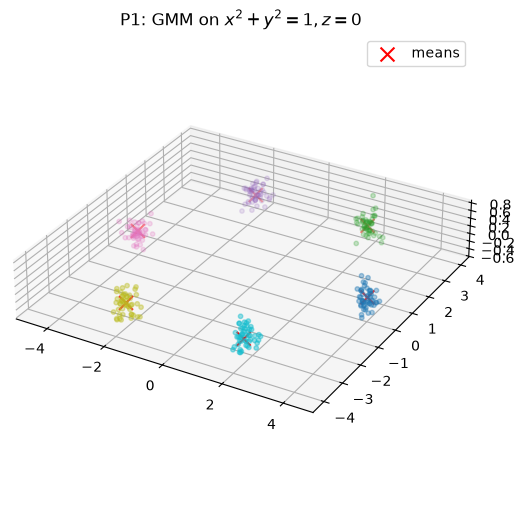

In [3]:
# ----------------------------
# Parameters
# ----------------------------
K = 6  # number of components
N = 300  # total number of samples
sigma = 0.2  # component standard deviation

# ----------------------------
# Six equally spaced points on the circle (means)
# ----------------------------
radius = 4
theta = np.linspace(0, 2 * np.pi, K, endpoint=False)
means = np.stack(
    [radius * np.cos(theta), radius * np.sin(theta), np.zeros(K)], axis=1
)  # shape (6, 3)

# ----------------------------
# Covariance (shared by every component)
# ----------------------------
Sigma = sigma**2 * np.eye(3)

# ----------------------------
# Sample from the GMM
# ----------------------------
points = []
labels = []

for k in range(K):
    Nk = N // K
    samples = np.random.multivariate_normal(mean=means[k], cov=Sigma, size=Nk)
    points.append(samples)
    labels.append(np.full(Nk, k))

P_1 = np.vstack(points)
labels = np.concatenate(labels)

# ----------------------------
# Visualization
# ----------------------------
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(P_1[:, 0], P_1[:, 1], P_1[:, 2], c=labels, cmap="tab10", s=10, alpha=0.7)

ax.scatter(
    means[:, 0], means[:, 1], means[:, 2], c="red", s=100, marker="x", label="means"
)

ax.set_title("P1: GMM on $x^2+y^2=1, z=0$")
ax.set_box_aspect([1, 1, 0.2])
ax.legend()
plt.show()

## The same ring in 2D

`P1_2d` repeats the construction in the plane, where it is easier to read than the squashed
3D view above. The next section lifts it back into 3D, and the assembly cell further down
reads its point count as `P1_2d.shape[0]`.

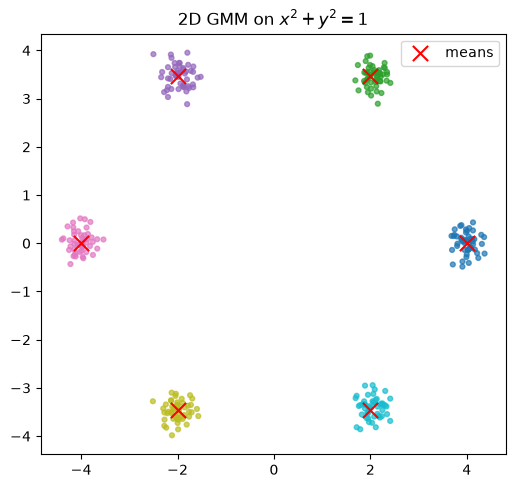

In [4]:
# ----------------------------
# Parameters
# ----------------------------
K = 6
N = 300
sigma = 0.2

# ----------------------------
# Six equally spaced points on the circle (means)
# ----------------------------
theta = np.linspace(0, 2 * np.pi, K, endpoint=False)
means_2d = np.stack([radius * np.cos(theta), radius * np.sin(theta)], axis=1)  # (6, 2)

# ----------------------------
# Covariance (shared)
# ----------------------------
Sigma_2d = sigma**2 * np.eye(2)

# ----------------------------
# Sampling
# ----------------------------
points_2d = []
labels_2d = []

for k in range(K):
    Nk = N // K
    samples = np.random.multivariate_normal(mean=means_2d[k], cov=Sigma_2d, size=Nk)
    points_2d.append(samples)
    labels_2d.append(np.full(Nk, k))

P1_2d = np.vstack(points_2d)
labels_2d = np.concatenate(labels_2d)

# ----------------------------
# Visualization
# ----------------------------
plt.figure(figsize=(6, 6))
plt.scatter(P1_2d[:, 0], P1_2d[:, 1], c=labels_2d, cmap="tab10", s=12, alpha=0.7)
plt.scatter(means_2d[:, 0], means_2d[:, 1], c="red", s=120, marker="x", label="means")
plt.gca().set_aspect("equal")
plt.title("2D GMM on $x^2 + y^2 = 1$")
plt.legend()
plt.show()

## Embedding the 2D ring back into 3D

Lift `P1_2d` and its means to $z = 0$ and redraw them in 3D — a visual check that the flat
ring and the 3D one agree.

In [5]:
P1_3d = np.hstack([P1_2d, np.zeros((P1_2d.shape[0], 1))])

# means_2d comes from the cell above
means_3d = np.hstack([means_2d, np.zeros((means_2d.shape[0], 1))])

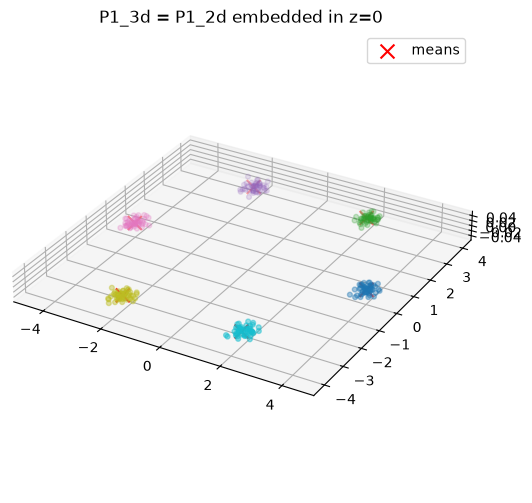

In [6]:
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    P1_3d[:, 0], P1_3d[:, 1], P1_3d[:, 2], c=labels_2d, cmap="tab10", s=12, alpha=0.7
)

ax.scatter(
    means_3d[:, 0],
    means_3d[:, 1],
    means_3d[:, 2],
    c="red",
    s=100,
    marker="x",
    label="means",
)

ax.set_title("P1_3d = P1_2d embedded in z=0")
ax.set_box_aspect([1, 1, 0.1])
ax.legend()
plt.show()

## The outlier blob

Ten points drawn uniformly inside a ball of radius $0.3$ centred at $(10, 0, 10)$, far from
the ring. The direction is a normalised Gaussian vector and the radius is scaled by
$u^{1/3}$ so the points fill the ball evenly instead of piling up near the centre. This is
the part of the target cloud that partial transport should be able to refuse.

In [7]:
n_noise = 10
noise_center = np.array([2.5 * radius, 0.0, 10.0])
noise_radius = 0.3

# Uniform direction on the sphere, radius scaled by u^(1/3) for a uniform ball
u = np.random.normal(size=(n_noise, 3))
u /= np.linalg.norm(u, axis=1, keepdims=True)
r_rand = noise_radius * np.random.uniform(0, 1, n_noise) ** (1 / 3)

P3 = noise_center + u * r_rand[:, None]

## Assembling the two clouds

The final source/target pair. Reading the cell top to bottom:

- `P2` is the 3D ring lifted to $z = 10$.
- `P1` is rebuilt from `P2` by dropping the $z$ coordinate, re-embedding at $z = 0$ and
  scaling by $2.5$: a flat ring of radius $10$ in the plane $z = 0$. This overwrites the
  `P1_3d` built in the previous section.
- `P23` stacks the lifted ring and the outlier blob, scales the result by $2$ and lifts it a
  further $5$: 310 points, a ring of radius $8$ at $z = 25$ plus the blob near
  $(20, 0, 25)$.

Source and target therefore differ by a change of scale and position **and** by the extra
blob — exactly the situation the partial methods are meant to handle.

In [8]:
# The ring, lifted to z = 10
P2 = P_1 + (0, 0, 10)

# Flatten it back to z = 0 and scale it up: the source cloud, a ring of radius 10
P1 = P2[:, :2]
P1_3d = np.hstack([P1, np.zeros((P1_2d.shape[0], 1))])
P1 = 2.5 * P1_3d

# The target cloud: ring + outlier blob, scaled by 2 and lifted a further 5
P23 = 2 * np.vstack([P2, P3]) + (0, 0, 5)

## Helper: equal aspect ratio in 3D

Matplotlib has no `set_aspect("equal")` for 3D axes, so the ring would be drawn as an
ellipse. This sets one common range on all three axes, centred on the data.

In [9]:
def set_equal_3d_axes(ax, points, margin=0.1):
    mins = points.min(axis=0)
    maxs = points.max(axis=0)

    center = 0.5 * (mins + maxs)
    radius = 0.5 * (maxs - mins).max()
    radius *= 1 + margin

    ax.set_xlim(center[0] - radius, center[0] + radius)
    ax.set_ylim(center[1] - radius, center[1] + radius)
    ax.set_zlim(center[2] - radius, center[2] + radius)

    ax.set_box_aspect([1, 1, 1])

## pMGW2 — partial mixture Gromov–Wasserstein

`pMGW2_coup` fits a 6-component mixture to `P1` and a 7-component mixture to `P23` — six for
the ring, one for the blob — solves a partial Gromov–Wasserstein problem between the two
sets of components, and pushes the points through the resulting barycentric map.
`Lambda=0.10` is the penalty paid for mass left unmatched, on the normalised cost scale.

With `points=True` the returned array holds, for each source point, the index of the nearest
point of `P23` to its image; 300 of those matches are drawn as orange segments.

Saves `pmgw_coupling.eps`.

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


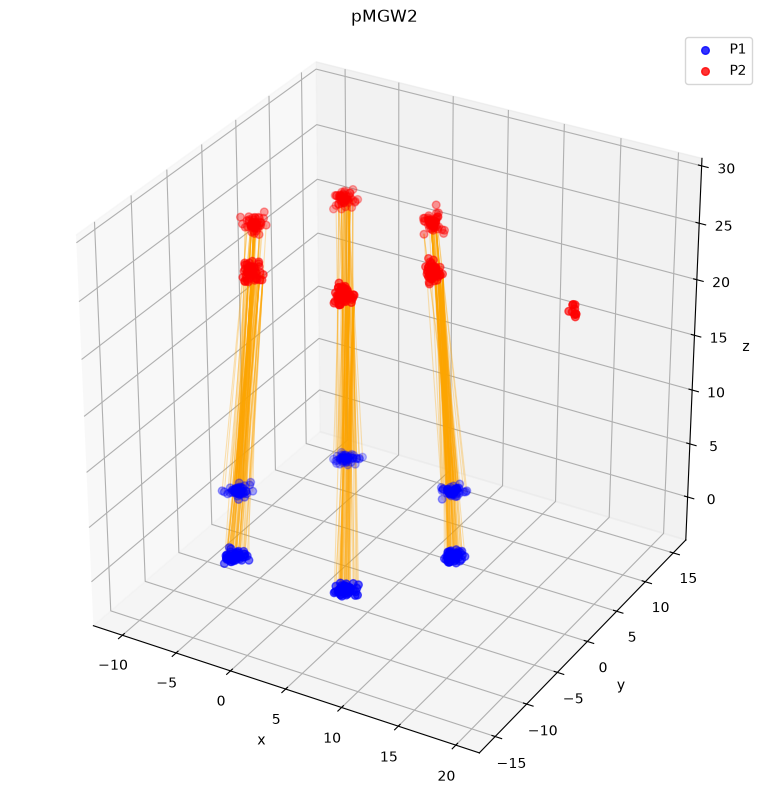

CPU times: user 1.33 s, sys: 21.7 ms, total: 1.35 s
Wall time: 1.5 s


In [10]:
%%time
idx = pMGW2_coup(
    X=P1,
    Y=P23,
    Lambda=0.10,
    n_components_X=6,
    n_components_Y=7,
    solver_tol=1e-12,
    points=True,  # returns indices into P23
)
# -------------------------
# Scale definition (matches the original figure)
# -------------------------
all_points = np.vstack([P1, P23])

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="3d")

# -------------------------
# Draw the point clouds
# -------------------------
ax.scatter(*P1.T, s=30, c="blue", label="P1", alpha=0.8)
ax.scatter(*P23.T, s=30, c="red", label="P2", alpha=0.8)

# -------------------------
# Matching segments
# -------------------------
num_lines = min(300, len(P1))  # avoid drawing too many
sample_idx = np.random.choice(len(P1), num_lines, replace=False)

for i in sample_idx:
    j = idx[i]
    ax.plot(
        [P1[i, 0], P23[j, 0]],
        [P1[i, 1], P23[j, 1]],
        [P1[i, 2], P23[j, 2]],
        c="orange",
        alpha=0.3,
        linewidth=0.8,
    )

# -------------------------
# Axis and display settings
# -------------------------
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("pMGW2")
ax.legend()

set_equal_3d_axes(ax, all_points)

plt.tight_layout()
plt.savefig("pmgw_coupling.eps", format="eps", dpi=500)
plt.show()

## pMGW2 — the barycentric map itself

The identical call with `points=False`, so `idx` now holds mapped **coordinates** rather
than indices into `P23`. Each segment ends wherever the map actually sends its source point,
which need not be on the target cloud.

Saves `pmgw_bary.eps`.

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


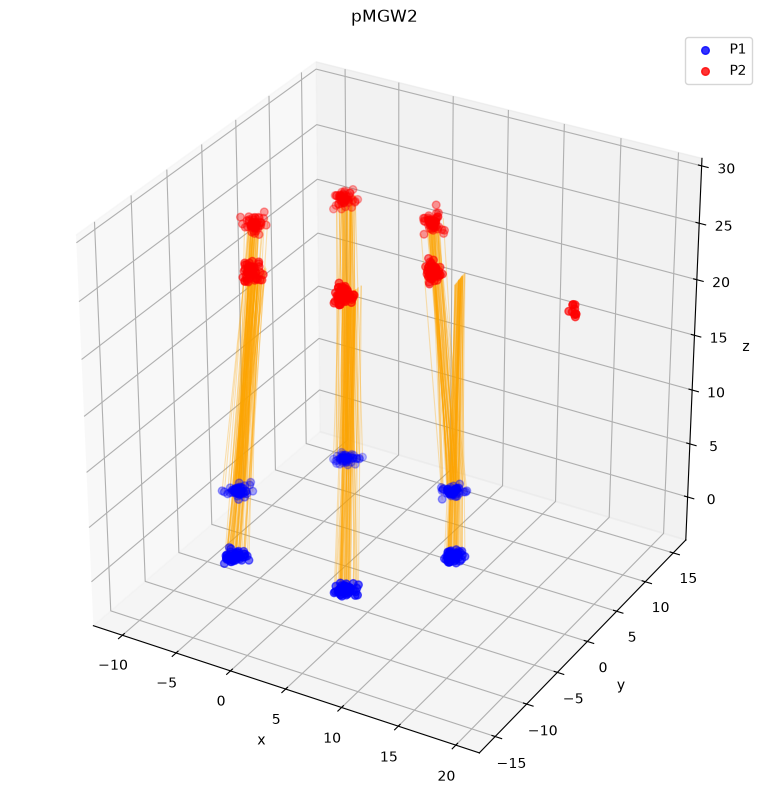

CPU times: user 1.67 s, sys: 66.1 ms, total: 1.74 s
Wall time: 2.28 s


In [11]:
%%time
idx = pMGW2_coup(
    X=P1,
    Y=P23,
    Lambda=0.10,
    n_components_X=6,
    n_components_Y=7,
    solver_tol=1e-12,
    points=False,  # returns barycentric projection points, not indices
)
# -------------------------
# Scale definition (matches the original figure)
# -------------------------
all_points = np.vstack([P1, P23])

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="3d")

# -------------------------
# Draw the point clouds
# -------------------------
ax.scatter(*P1.T, s=30, c="blue", label="P1", alpha=0.8)
ax.scatter(*P23.T, s=30, c="red", label="P2", alpha=0.8)

# -------------------------
# Matching segments
# -------------------------
num_lines = min(300, len(P1))  # avoid drawing too many
sample_idx = np.random.choice(len(P1), num_lines, replace=False)

for i in sample_idx:
    mapped_point = idx[i]  # idx[i] is already a coordinate
    ax.plot(
        [P1[i, 0], mapped_point[0]],
        [P1[i, 1], mapped_point[1]],
        [P1[i, 2], mapped_point[2]],
        c="orange",
        alpha=0.3,
        linewidth=0.8,
    )

# -------------------------
# Axis and display settings
# -------------------------
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("pMGW2")
ax.legend()

set_equal_3d_axes(ax, all_points)

plt.tight_layout()
plt.savefig("pmgw_bary.eps", format="eps", dpi=500)
plt.show()

## MGW2 — balanced mixture Gromov–Wasserstein

The same idea without the partial relaxation. `MGW2_coup` fits 6 components to each cloud
and has to transport all of the mass, so the outlier blob is matched whether it belongs or
not. `method="T_mean"` selects the deterministic barycentric map rather than the randomised
one.

Saves `mgw_coupling.eps`.

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


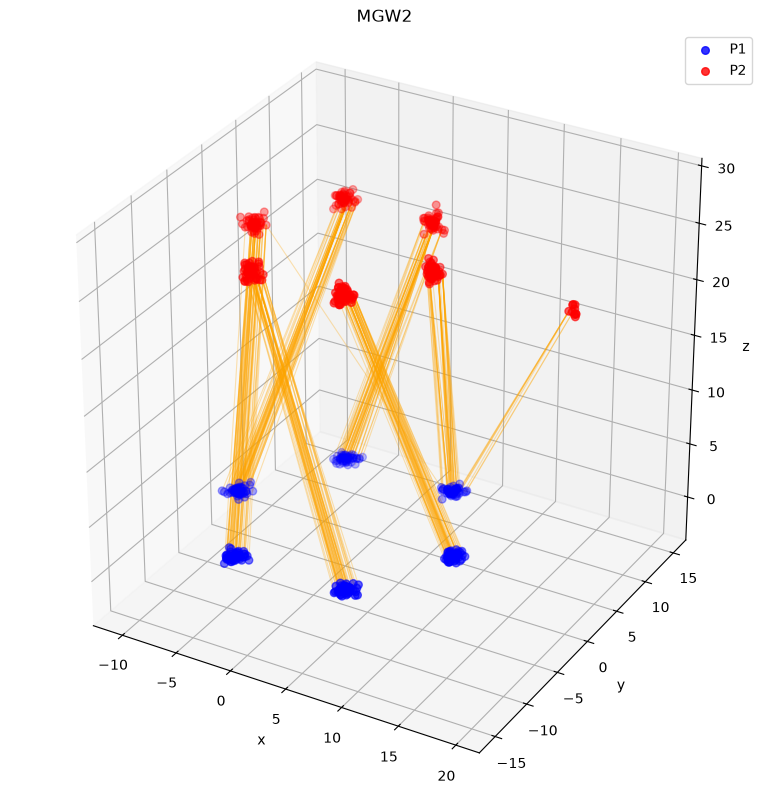

CPU times: user 1.42 s, sys: 30.8 ms, total: 1.45 s
Wall time: 1.62 s


In [12]:
%%time
idy = MGW2_coup(
    X=P1,
    Y=P23,
    n_components=6,
    annealing=False,
    method="T_mean",
    points=True,  # returns indices into P23
    return_both=False,
    verbose=False,
)
# -------------------------
# Scale definition (matches the original figure)
# -------------------------
all_points = np.vstack([P1, P23])

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="3d")

# -------------------------
# Draw the point clouds
# -------------------------
ax.scatter(*P1.T, s=30, c="blue", label="P1", alpha=0.8)
ax.scatter(*P23.T, s=30, c="red", label="P2", alpha=0.8)

# -------------------------
# Matching segments
# -------------------------
num_lines = min(300, len(P1))  # avoid drawing too many
sample_idy = np.random.choice(len(P1), num_lines, replace=False)

for i in sample_idy:
    j = idy[i]
    ax.plot(
        [P1[i, 0], P23[j, 0]],
        [P1[i, 1], P23[j, 1]],
        [P1[i, 2], P23[j, 2]],
        c="orange",
        alpha=0.3,
        linewidth=0.8,
    )

# -------------------------
# Axis and display settings
# -------------------------
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("MGW2")
ax.legend()

set_equal_3d_axes(ax, all_points)

plt.tight_layout()
plt.savefig("mgw_coupling.eps", format="eps", dpi=500)
plt.show()

## MGW2 — the barycentric map itself

`points=False` again, so `bidy` holds mapped coordinates rather than indices into `P23`.

Saves `mgw_bary.eps`.

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


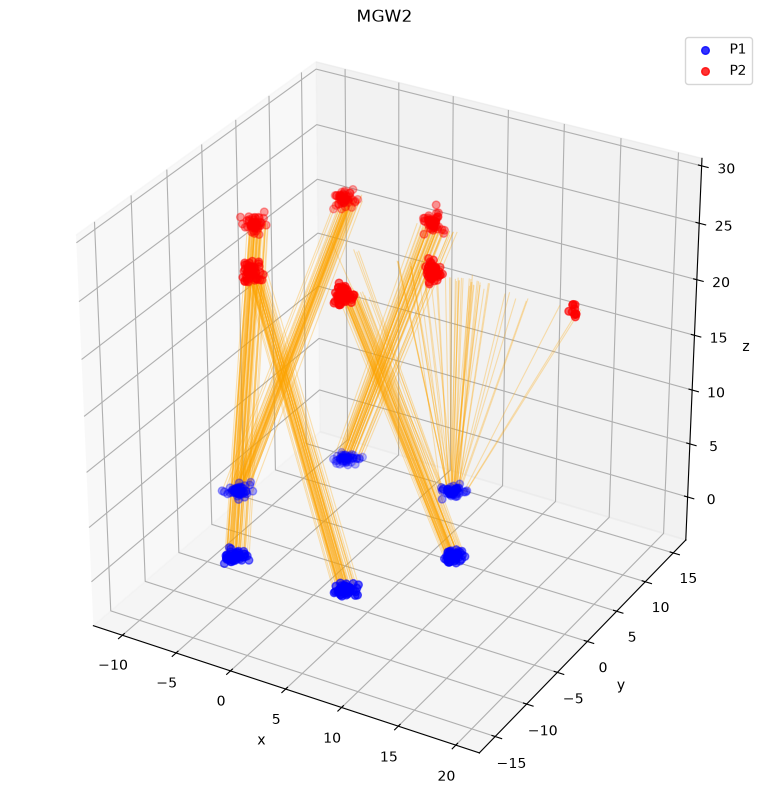

CPU times: user 1.46 s, sys: 1.21 ms, total: 1.46 s
Wall time: 1.75 s


In [13]:
%%time
bidy = MGW2_coup(
    X=P1,
    Y=P23,
    n_components=6,
    annealing=False,
    method="T_mean",
    points=False,  # returns mapped coordinates, not indices
    return_both=False,
    verbose=False,
)
# -------------------------
# Scale definition (matches the original figure)
# -------------------------
all_points = np.vstack([P1, P23])

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="3d")

# -------------------------
# Draw the point clouds
# -------------------------
ax.scatter(*P1.T, s=30, c="blue", label="P1", alpha=0.8)
ax.scatter(*P23.T, s=30, c="red", label="P2", alpha=0.8)

# -------------------------
# Matching segments
# -------------------------
num_lines = min(300, len(P1))  # avoid drawing too many
sample_idy = np.random.choice(len(P1), num_lines, replace=False)

for i in sample_idy:
    mapped_point = bidy[i]  # bidy[i] is already a coordinate
    ax.plot(
        [P1[i, 0], mapped_point[0]],
        [P1[i, 1], mapped_point[1]],
        [P1[i, 2], mapped_point[2]],
        c="orange",
        alpha=0.3,
        linewidth=0.8,
    )

# -------------------------
# Axis and display settings
# -------------------------
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("MGW2")
ax.legend()

set_equal_3d_axes(ax, all_points)

plt.tight_layout()
plt.savefig("mgw_bary.eps", format="eps", dpi=500)
plt.show()

## GW2 — Gromov–Wasserstein on the raw points

No mixture step at all. Build the $300 \times 300$ and $310 \times 310$ intra-cloud distance
matrices, normalise both by the same maximum so the two scales are comparable, and solve a
balanced Gromov–Wasserstein problem directly on the points. Only the highest-probability
target is drawn for each source point; with 300 × 310 entries, drawing every coupling would
be unreadable.

Saves `gw_coupling.eps`.

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


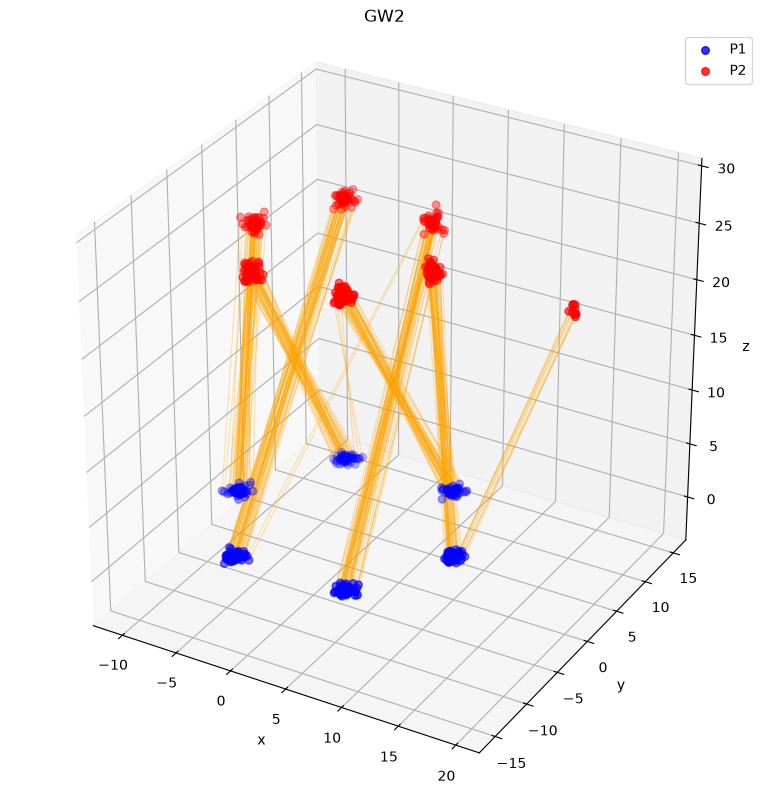

CPU times: user 1.34 s, sys: 30.9 ms, total: 1.37 s
Wall time: 1.37 s


In [14]:
%%time
# 1. Compute the distance matrices, normalised by a common maximum
C1 = ot.dist(P1, P1)
C23 = ot.dist(P23, P23)

M1 = np.max(C1)
M2 = np.max(C23)
M = np.max([M1, M2])
C1 = C1 / M
C23 = C23 / M

# 2. Set the weights (uniform)
p = ot.unif(len(P1))
q = ot.unif(len(P23))

# 3. Compute the Gromov-Wasserstein transport matrix.
# Matching based only on the relative geometry of P1 and P23.
G = ot.gromov_wasserstein(C1, C23, p, q, "square_loss", epsilon=5e-3)

# --- Visualization ---
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="3d")

# Used to derive the axis ranges from all points combined
all_points = np.vstack([P1, P23])

# Draw the point clouds
ax.scatter(P1[:, 0], P1[:, 1], P1[:, 2], color="blue", label="P1", s=30, alpha=0.8)
ax.scatter(P23[:, 0], P23[:, 1], P23[:, 2], color="red", label="P2", s=30, alpha=0.8)

# One line per source point, to its most likely target
for i in range(len(P1)):
    j = np.argmax(G[i, :])
    if G[i, j] > 1e-5:  # significant couplings only
        ax.plot(
            [P1[i, 0], P23[j, 0]],
            [P1[i, 1], P23[j, 1]],
            [P1[i, 2], P23[j, 2]],
            color="orange",
            alpha=0.3,
            linewidth=0.8,
        )

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("GW2")
ax.legend()

set_equal_3d_axes(ax, all_points)

plt.tight_layout()
plt.savefig("gw_coupling.eps", format="eps", dpi=500)
plt.show()

## PGW2 — partial Gromov–Wasserstein on the raw points

The partial counterpart of the previous cell, using `partial_gromov_ver1` from the vendored
`PGW_Metric` code: the same normalised distance matrices, but mass may be left behind for a
penalty of `Lambda=0.04`, tuned to the scale of those normalised distances. Only pairs
carrying more than $0.1/n_1$ of mass are drawn, which is how unmatched source points drop
out of the picture.

Saves `pgw_coupling.eps`.

It.  |Err         |Loss        
-------------------------------
    0|4.588262e-02|2.065757e-02


/home/yukimura/EPOT-pMGW/.venv/lib/python3.13/site-packages/lib/gromov.py:790: UserWarning: This function will be deprecated in a near future, please use ot.gromov.gwloss` instead.
  print("{:5d}|{:8e}|{:8e}".format(cpt, err, gwloss_partial(C1, C2, G0)))
/home/yukimura/EPOT-pMGW/.venv/lib/python3.13/site-packages/ot/partial/partial_solvers.py:887: UserWarning: This function will be deprecated in a near future, please use ot.gromov.gwggrad` instead.
  g = gwgrad_partial(C1, C2, T) * 0.5


Calculation time: 0.277034 sec
Total transported mass: 0.9677


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


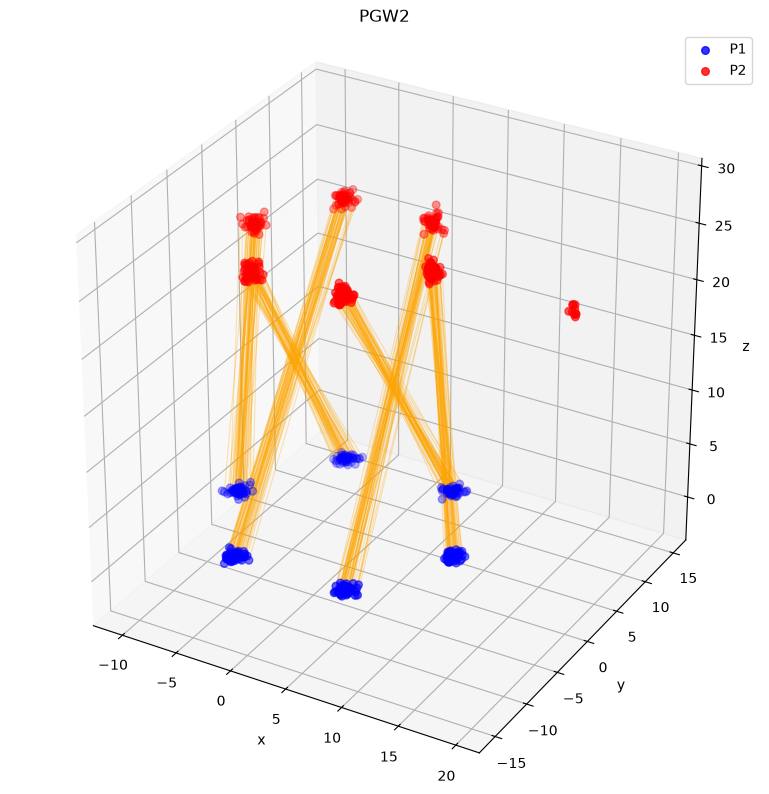

In [15]:
# P1 is the source cloud and P23 the target; P23 has the extra points, so only part of
# it can be matched. Lambda penalises mass left behind: the smaller it is, the less the
# solver forces connections.
n1, n2 = len(P1), len(P23)
C1 = ot.dist(P1, P1)
C23 = ot.dist(P23, P23)
M1 = np.max(C1)
M2 = np.max(C23)
M = np.max([M1, M2])
C1 = C1 / M
C23 = C23 / M

# Set the weights (uniform)
p = np.ones(n1) / n1
q = np.ones(n2) / n2

start_time = time.time()

# Compute the partial Gromov-Wasserstein plan
G_partial = gromov.partial_gromov_ver1(
    C1,
    C23,
    p,
    q,
    Lambda=0.04,  # tuned to the scale of the normalised distances
    numItermax_gw=100,
    verbose=True,
)

print(f"Calculation time: {time.time() - start_time:.6f} sec")
print(f"Total transported mass: {np.sum(G_partial):.4f}")

# --- Visualization ---
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="3d")

all_points = np.vstack([P1, P23])

# Draw the point clouds
ax.scatter(P1[:, 0], P1[:, 1], P1[:, 2], color="blue", label="P1", s=30, alpha=0.8)
ax.scatter(P23[:, 0], P23[:, 1], P23[:, 2], color="red", label="P2", s=30, alpha=0.8)

# For each source point, the target it is most strongly coupled to. Points carrying
# almost no mass were dropped by the partial solver, so they get no line at all.
for i in range(len(P1)):
    j = np.argmax(G_partial[i, :])
    if G_partial[i, j] > (0.1 / n1):
        ax.plot(
            [P1[i, 0], P23[j, 0]],
            [P1[i, 1], P23[j, 1]],
            [P1[i, 2], P23[j, 2]],
            color="orange",
            alpha=0.3,
            linewidth=0.8,
        )

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("PGW2")
ax.legend()

set_equal_3d_axes(ax, all_points)

plt.tight_layout()
plt.savefig("pgw_coupling.eps", format="eps", dpi=500)
plt.show()